# Big Mart Sales Analysis and Prediction

## Thiranex Internship — Task 4

This project performs end-to-end analysis and sales prediction using the Big Mart Sales dataset.

### Objectives
- Understand and clean the retail sales dataset
- Perform exploratory data analysis
- Identify important sales patterns and factors
- Create meaningful visualizations
- Build machine learning models for sales prediction
- Evaluate and compare model performance
- Present business insights and conclusions

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
# File paths
train_path = "/content/drive/MyDrive/Thiranex/Task-4/Big-Mart Sales/train.csv"
test_path = "/content/drive/MyDrive/Thiranex/Task-4/Big-Mart Sales/test.csv"

# Load datasets
train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Training dataset loaded successfully.")
print("Test dataset loaded successfully.")

Training dataset loaded successfully.
Test dataset loaded successfully.


In [5]:
print("Training Dataset Shape:", train_df.shape)
print("Test Dataset Shape:", test_df.shape)

Training Dataset Shape: (8523, 12)
Test Dataset Shape: (5681, 11)


In [6]:
train_df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


In [7]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [8]:
print("Training Dataset Columns:")

for i, column in enumerate(train_df.columns, start=1):
    print(f"{i}. {column}")

Training Dataset Columns:
1. Item_Identifier
2. Item_Weight
3. Item_Fat_Content
4. Item_Visibility
5. Item_Type
6. Item_MRP
7. Outlet_Identifier
8. Outlet_Establishment_Year
9. Outlet_Size
10. Outlet_Location_Type
11. Outlet_Type
12. Item_Outlet_Sales


In [9]:
train_df.describe()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
count,7060.000000,8523.000000,8523.000000,8523.000000,8523.000000
mean,12.857645,0.066132,140.992782,1997.831867,2181.288914
std,4.643456,0.051598,62.275067,8.371760,1706.499616
min,4.555000,0.000000,31.290000,1985.000000,33.290000
25%,8.773750,0.026989,93.826500,1987.000000,834.247400
50%,12.600000,0.053931,143.012800,1999.000000,1794.331000
75%,16.850000,0.094585,185.643700,2004.000000,3101.296400
max,21.350000,0.328391,266.888400,2009.000000,13086.964800


In [10]:
missing_values = train_df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(train_df)) * 100
})

missing_table.sort_values(
    by="Missing Values",
    ascending=False
)

,Missing Values,Percentage
Outlet_Size,2410,28.276428
Item_Weight,1463,17.165317
Item_Fat_Content,0,0.000000
Item_Identifier,0,0.000000
Item_Visibility,0,0.000000
Item_Type,0,0.000000
Outlet_Identifier,0,0.000000
Item_MRP,0,0.000000
Outlet_Establishment_Year,0,0.000000
Outlet_Location_Type,0,0.000000


In [11]:
duplicates = train_df.duplicated().sum()

print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [12]:
# Create copies
df = train_df.copy()
test = test_df.copy()

# Numerical column
df["Item_Weight"] = df["Item_Weight"].fillna(
    df["Item_Weight"].median()
)

test["Item_Weight"] = test["Item_Weight"].fillna(
    test["Item_Weight"].median()
)

# Categorical columns
df["Outlet_Size"] = df["Outlet_Size"].fillna(
    df["Outlet_Size"].mode()[0]
)

test["Outlet_Size"] = test["Outlet_Size"].fillna(
    test["Outlet_Size"].mode()[0]
)

# Check missing values
print("Remaining missing values in training data:")
print(df.isnull().sum())

Remaining missing values in training data:
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


In [13]:
print("Target Variable: Item_Outlet_Sales")

print("\nTarget Statistics:")
print(df["Item_Outlet_Sales"].describe())

Target Variable: Item_Outlet_Sales

Target Statistics:
count     8523.000000
mean      2181.288914
std       1706.499616
min         33.290000
25%        834.247400
50%       1794.331000
75%       3101.296400
max      13086.964800
Name: Item_Outlet_Sales, dtype: float64


In [14]:
item_type_counts = df["Item_Type"].value_counts()

print(item_type_counts)

Item_Type
Fruits and Vegetables    1232
Snack Foods              1200
Household                 910
Frozen Foods              856
Dairy                     682
Canned                    649
Baking Goods              648
Health and Hygiene        520
Soft Drinks               445
Meat                      425
Breads                    251
Hard Drinks               214
Others                    169
Starchy Foods             148
Breakfast                 110
Seafood                    64
Name: count, dtype: int64


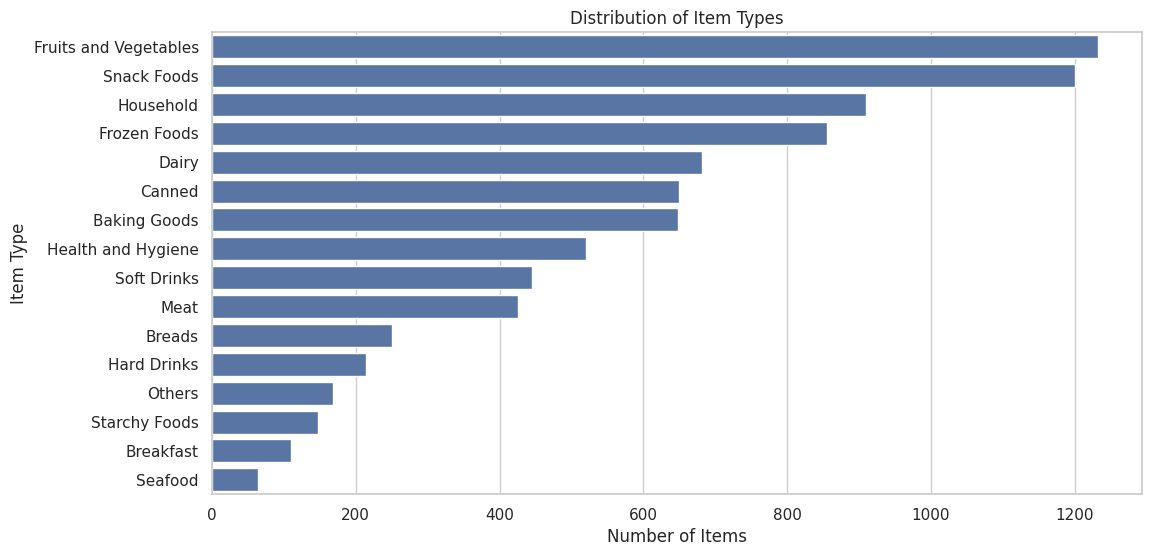

In [15]:
plt.figure(figsize=(12, 6))

sns.countplot(
    data=df,
    y="Item_Type",
    order=df["Item_Type"].value_counts().index
)

plt.title("Distribution of Item Types")
plt.xlabel("Number of Items")
plt.ylabel("Item Type")

plt.show()

In [16]:
avg_sales_item_type = (
    df.groupby("Item_Type")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_item_type)

Item_Type
Starchy Foods            2374.332773
Seafood                  2326.065928
Fruits and Vegetables    2289.009592
Snack Foods              2277.321739
Household                2258.784300
Dairy                    2232.542597
Canned                   2225.194904
Breads                   2204.132226
Meat                     2158.977911
Hard Drinks              2139.221622
Frozen Foods             2132.867744
Breakfast                2111.808651
Health and Hygiene       2010.000265
Soft Drinks              2006.511735
Baking Goods             1952.971207
Others                   1926.139702
Name: Item_Outlet_Sales, dtype: float64


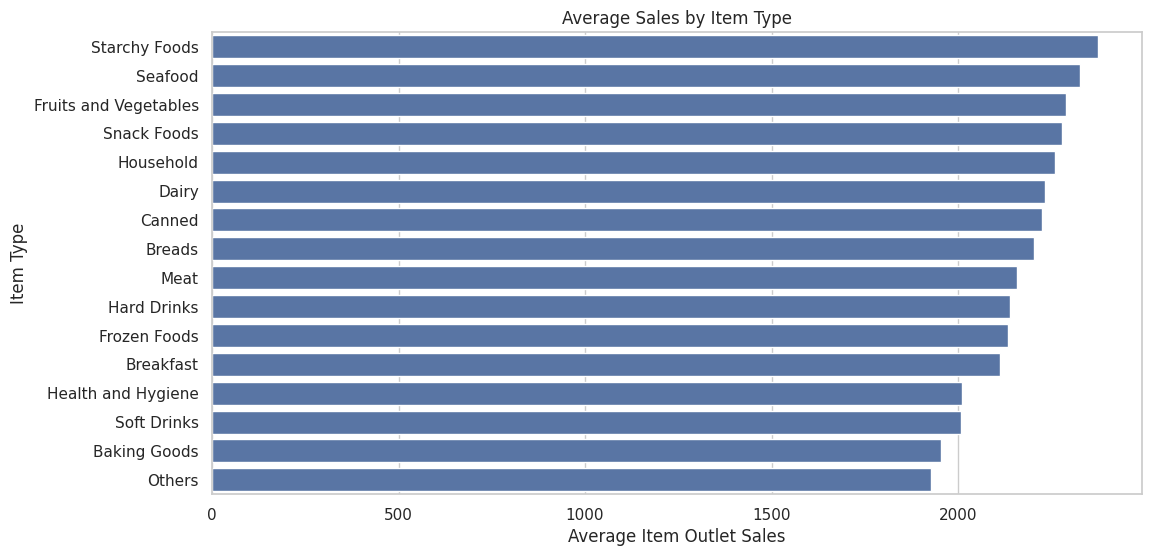

In [17]:
plt.figure(figsize=(12, 6))

sns.barplot(
    x=avg_sales_item_type.values,
    y=avg_sales_item_type.index
)

plt.title("Average Sales by Item Type")
plt.xlabel("Average Item Outlet Sales")
plt.ylabel("Item Type")

plt.show()

In [18]:
outlet_type_counts = df["Outlet_Type"].value_counts()

print(outlet_type_counts)

Outlet_Type
Supermarket Type1    5577
Grocery Store        1083
Supermarket Type3     935
Supermarket Type2     928
Name: count, dtype: int64


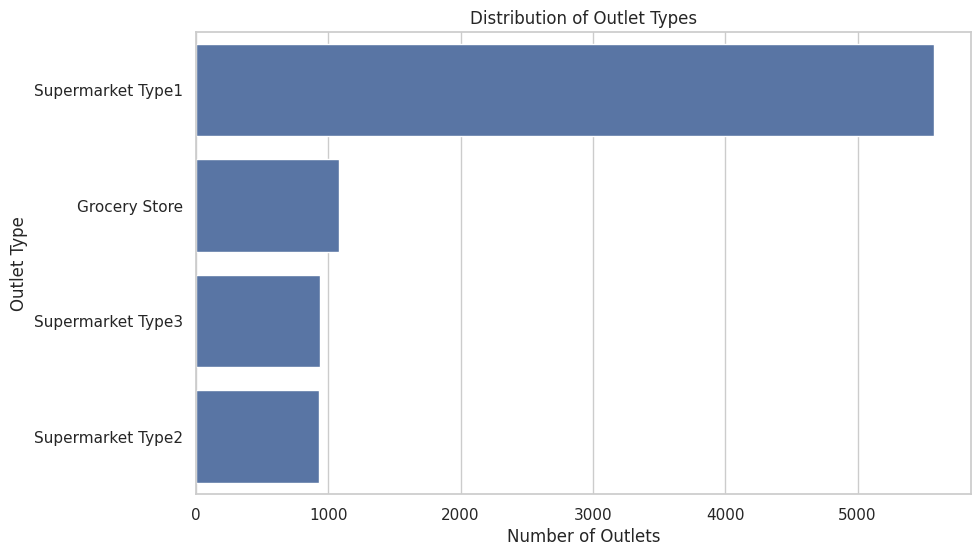

In [19]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    y="Outlet_Type",
    order=df["Outlet_Type"].value_counts().index
)

plt.title("Distribution of Outlet Types")
plt.xlabel("Number of Outlets")
plt.ylabel("Outlet Type")

plt.show()

In [20]:
avg_sales_outlet = (
    df.groupby("Outlet_Type")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_outlet)

Outlet_Type
Supermarket Type3    3694.038558
Supermarket Type1    2316.181148
Supermarket Type2    1995.498739
Grocery Store         339.828500
Name: Item_Outlet_Sales, dtype: float64


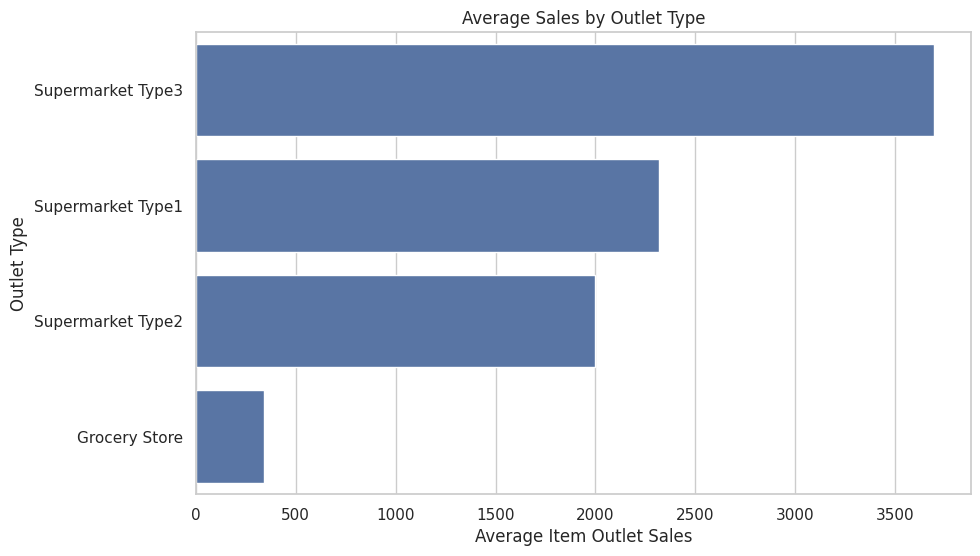

In [21]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_sales_outlet.values,
    y=avg_sales_outlet.index
)

plt.title("Average Sales by Outlet Type")
plt.xlabel("Average Item Outlet Sales")
plt.ylabel("Outlet Type")

plt.show()

In [22]:
location_counts = df["Outlet_Location_Type"].value_counts()

print(location_counts)

Outlet_Location_Type
Tier 3    3350
Tier 2    2785
Tier 1    2388
Name: count, dtype: int64


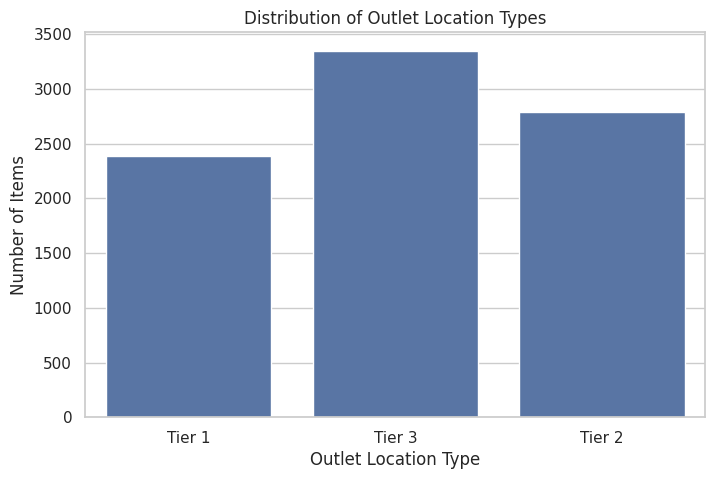

In [23]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Outlet_Location_Type"
)

plt.title("Distribution of Outlet Location Types")
plt.xlabel("Outlet Location Type")
plt.ylabel("Number of Items")

plt.show()

In [24]:
avg_sales_location = (
    df.groupby("Outlet_Location_Type")["Item_Outlet_Sales"]
    .mean()
    .sort_values(ascending=False)
)

print(avg_sales_location)

Outlet_Location_Type
Tier 2    2323.990559
Tier 3    2279.627651
Tier 1    1876.909159
Name: Item_Outlet_Sales, dtype: float64


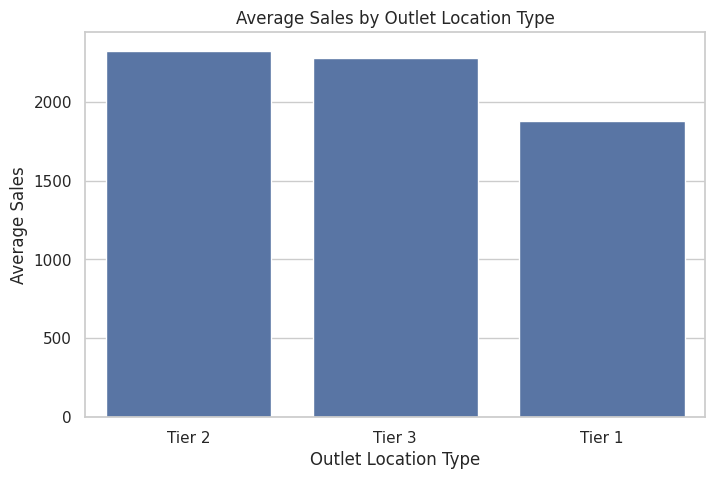

In [25]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_sales_location.index,
    y=avg_sales_location.values
)

plt.title("Average Sales by Outlet Location Type")
plt.xlabel("Outlet Location Type")
plt.ylabel("Average Sales")

plt.show()

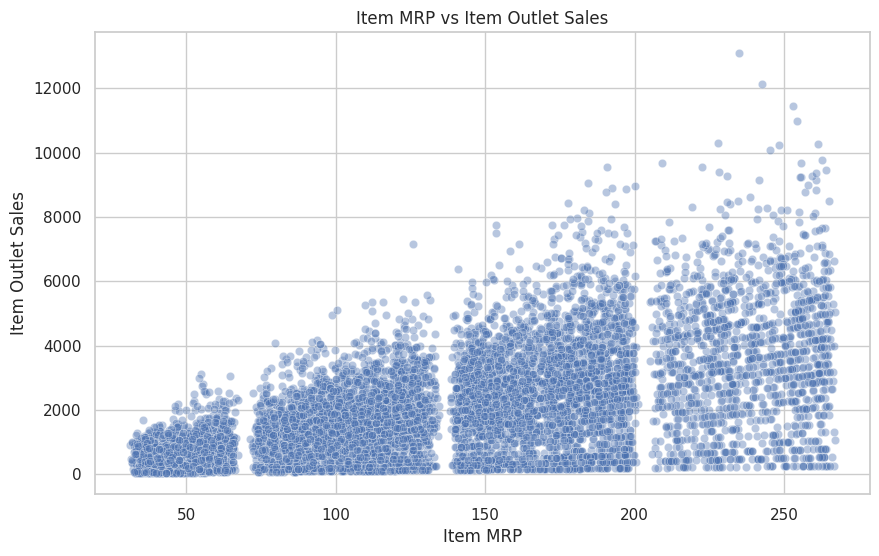

In [26]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Item_MRP",
    y="Item_Outlet_Sales",
    alpha=0.4
)

plt.title("Item MRP vs Item Outlet Sales")
plt.xlabel("Item MRP")
plt.ylabel("Item Outlet Sales")

plt.show()

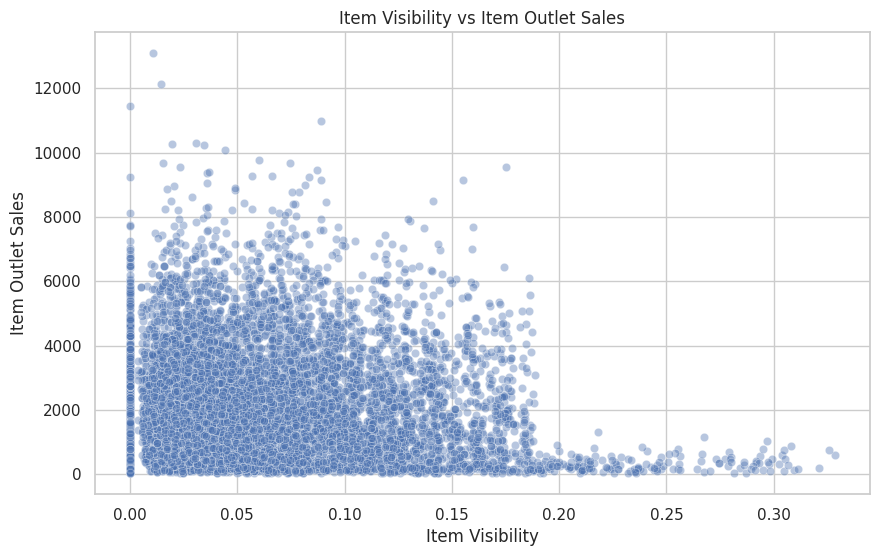

In [27]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Item_Visibility",
    y="Item_Outlet_Sales",
    alpha=0.4
)

plt.title("Item Visibility vs Item Outlet Sales")
plt.xlabel("Item Visibility")
plt.ylabel("Item Outlet Sales")

plt.show()

In [28]:
avg_sales_year = (
    df.groupby("Outlet_Establishment_Year")["Item_Outlet_Sales"]
    .mean()
)

print(avg_sales_year)

Outlet_Establishment_Year
1985    2483.677474
1987    2298.995256
1997    2277.844267
1998     339.351662
1999    2348.354635
2002    2192.384798
2004    2438.841866
2007    2340.675263
2009    1995.498739
Name: Item_Outlet_Sales, dtype: float64


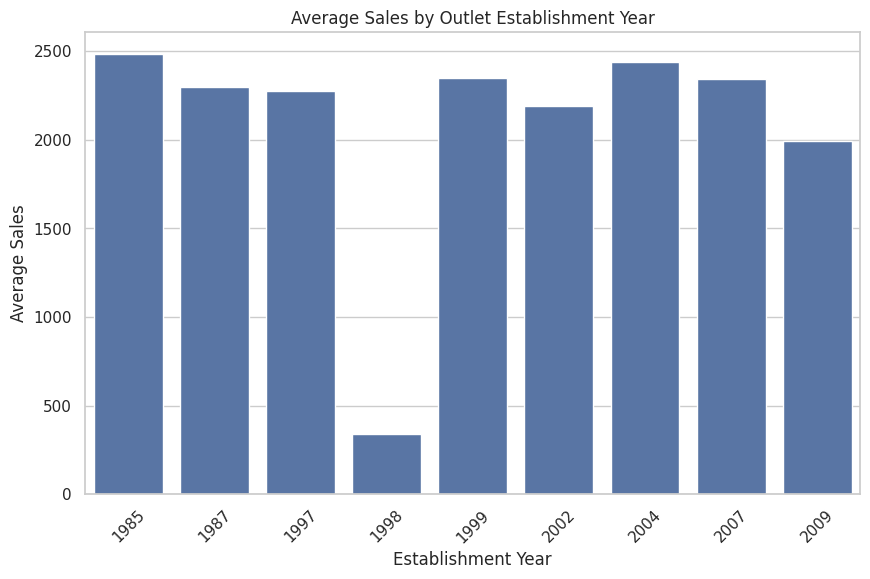

In [29]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_sales_year.index.astype(str),
    y=avg_sales_year.values
)

plt.title("Average Sales by Outlet Establishment Year")
plt.xlabel("Establishment Year")
plt.ylabel("Average Sales")

plt.xticks(rotation=45)

plt.show()

In [30]:
fat_counts = df["Item_Fat_Content"].value_counts()

print(fat_counts)

Item_Fat_Content
Low Fat    5089
Regular    2889
LF          316
reg         117
low fat     112
Name: count, dtype: int64


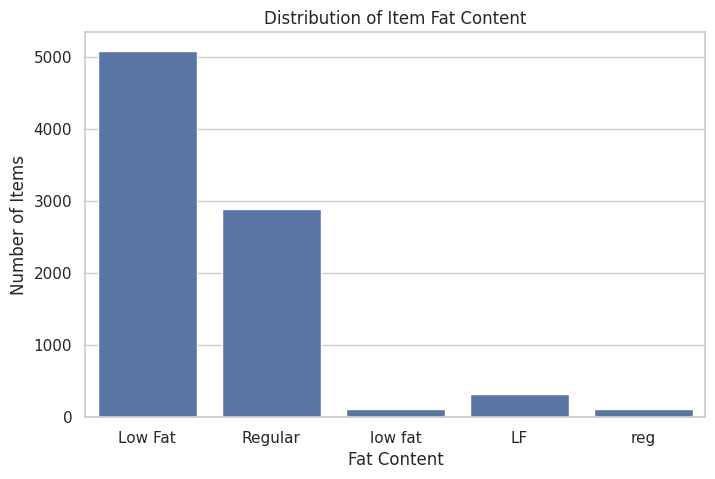

In [31]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Item_Fat_Content"
)

plt.title("Distribution of Item Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Number of Items")

plt.show()

In [32]:
avg_sales_fat = (
    df.groupby("Item_Fat_Content")["Item_Outlet_Sales"]
    .mean()
)

print(avg_sales_fat)

Item_Fat_Content
LF         2073.551928
Low Fat    2164.477336
Regular    2235.186702
low fat    2087.740737
reg        1962.192268
Name: Item_Outlet_Sales, dtype: float64


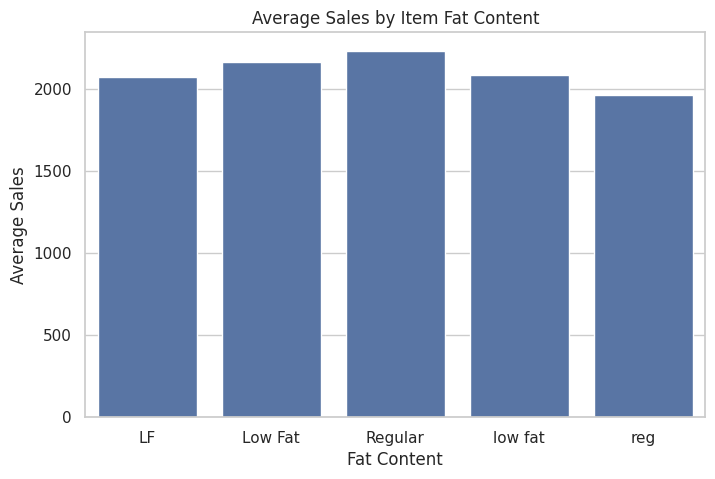

In [33]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=avg_sales_fat.index,
    y=avg_sales_fat.values
)

plt.title("Average Sales by Item Fat Content")
plt.xlabel("Fat Content")
plt.ylabel("Average Sales")

plt.show()

In [34]:
numerical_columns = [
    "Item_Weight",
    "Item_Visibility",
    "Item_MRP",
    "Outlet_Establishment_Year",
    "Item_Outlet_Sales"
]

correlation_matrix = df[numerical_columns].corr()

correlation_matrix

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales
Item_Weight,1.000000,-0.014168,0.024951,0.007739,0.009693
Item_Visibility,-0.014168,1.000000,-0.001315,-0.074834,-0.128625
Item_MRP,0.024951,-0.001315,1.000000,0.005020,0.567574
Outlet_Establishment_Year,0.007739,-0.074834,0.005020,1.000000,-0.049135
Item_Outlet_Sales,0.009693,-0.128625,0.567574,-0.049135,1.000000


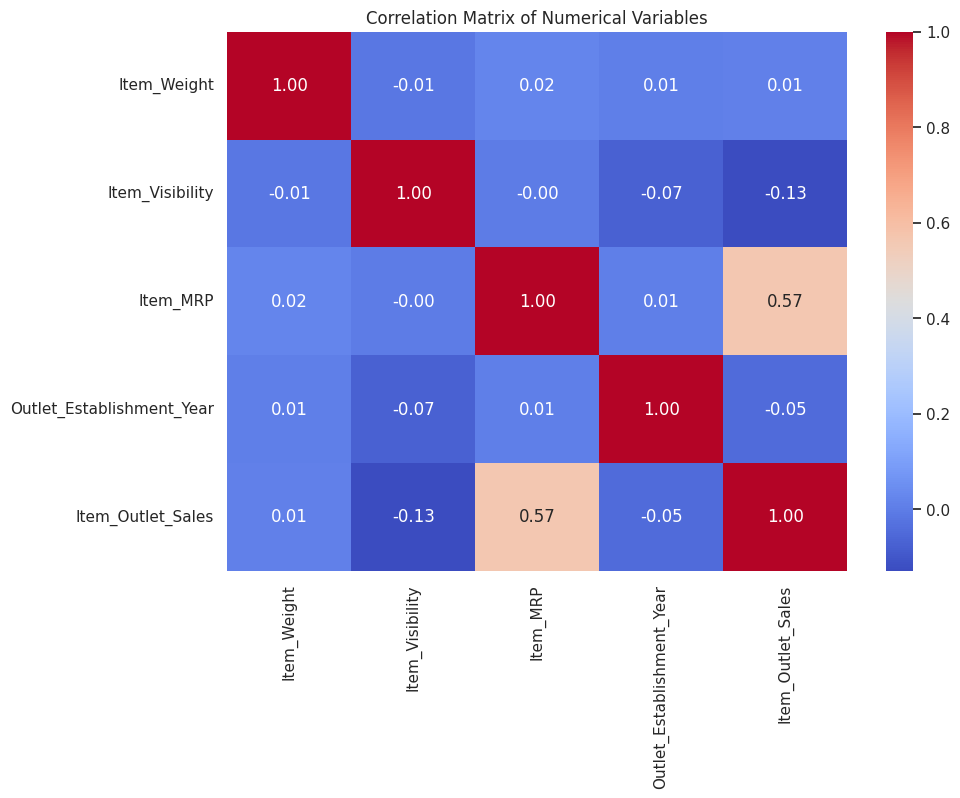

In [35]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

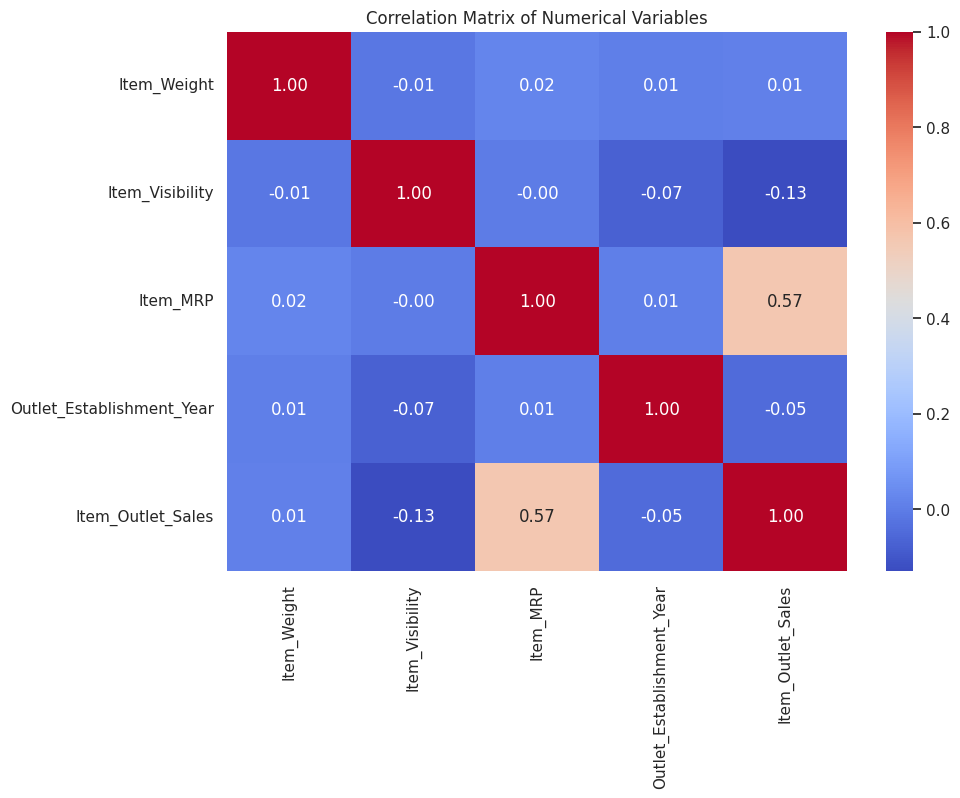

In [36]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Numerical Variables")

plt.show()

In [37]:
# Standardize Item Fat Content categories

df["Item_Fat_Content"] = df["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

test["Item_Fat_Content"] = test["Item_Fat_Content"].replace({
    "LF": "Low Fat",
    "low fat": "Low Fat",
    "reg": "Regular"
})

print(df["Item_Fat_Content"].value_counts())

Item_Fat_Content
Low Fat    5517
Regular    3006
Name: count, dtype: int64


In [38]:
# Separate features and target

X = df.drop(
    columns=["Item_Outlet_Sales"]
)

y = df["Item_Outlet_Sales"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (8523, 11)
Target shape: (8523,)


In [39]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    exclude=["object"]
).columns.tolist()

print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
['Item_Identifier', 'Item_Fat_Content', 'Item_Type', 'Outlet_Identifier', 'Outlet_Size', 'Outlet_Location_Type', 'Outlet_Type']

Numerical Features:
['Item_Weight', 'Item_Visibility', 'Item_MRP', 'Outlet_Establishment_Year']


In [40]:
X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 6818
Validation samples: 1705


In [41]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),
        (
            "numerical",
            "passthrough",
            numerical_features
        )
    ]
)

print("Preprocessing pipeline created.")

Preprocessing pipeline created.


In [42]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_predictions = linear_model.predict(X_val)

print("Linear Regression model trained.")

Linear Regression model trained.


In [43]:
decision_tree_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            DecisionTreeRegressor(
                max_depth=8,
                random_state=42
            )
        )
    ]
)

decision_tree_model.fit(
    X_train,
    y_train
)

decision_tree_predictions = decision_tree_model.predict(X_val)

print("Decision Tree model trained.")

Decision Tree model trained.


In [44]:
random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=200,
                max_depth=12,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

random_forest_predictions = random_forest_model.predict(X_val)

print("Random Forest model trained.")

Random Forest model trained.


In [45]:
def evaluate_model(name, actual, predictions):

    mae = mean_absolute_error(
        actual,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            actual,
            predictions
        )
    )

    r2 = r2_score(
        actual,
        predictions
    )

    return {
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2
    }

In [46]:
results = []

results.append(
    evaluate_model(
        "Linear Regression",
        y_val,
        linear_predictions
    )
)

results.append(
    evaluate_model(
        "Decision Tree",
        y_val,
        decision_tree_predictions
    )
)

results.append(
    evaluate_model(
        "Random Forest",
        y_val,
        random_forest_predictions
    )
)

results_df = pd.DataFrame(results)

results_df

,Model,MAE,RMSE,R2 Score
0,Linear Regression,939.175117,1267.551306,0.408865
1,Decision Tree,739.328842,1065.904694,0.581985
2,Random Forest,723.545222,1035.825057,0.605245


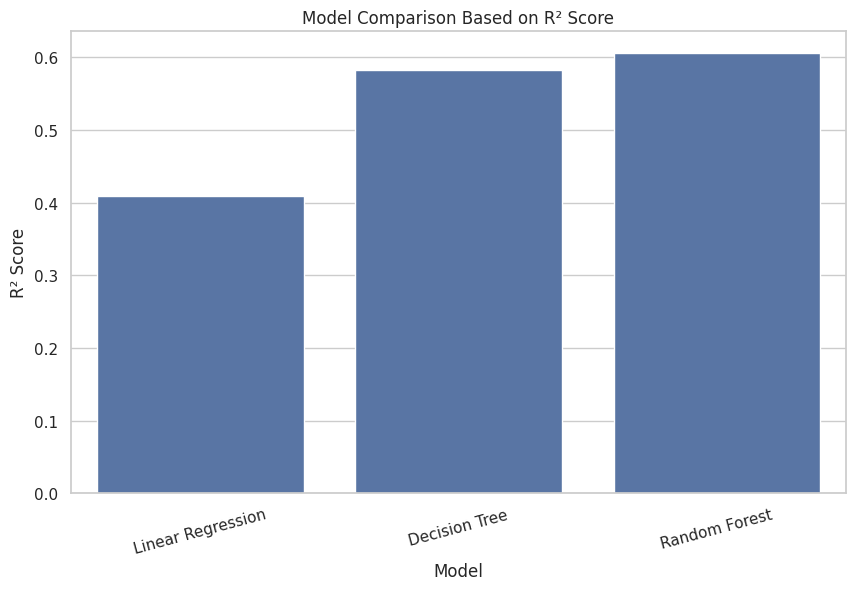

In [47]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison Based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

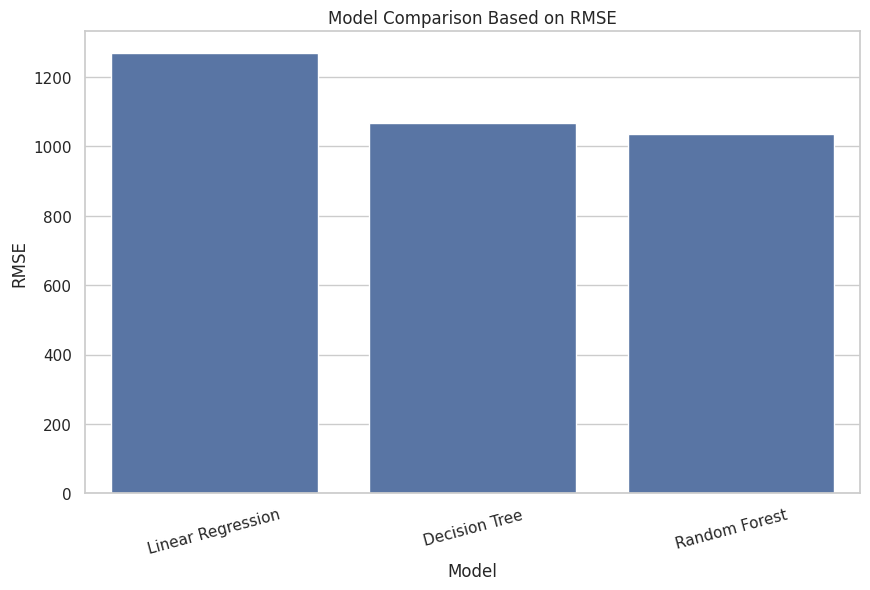

In [48]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=results_df,
    x="Model",
    y="RMSE"
)

plt.title("Model Comparison Based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")

plt.xticks(rotation=15)

plt.show()

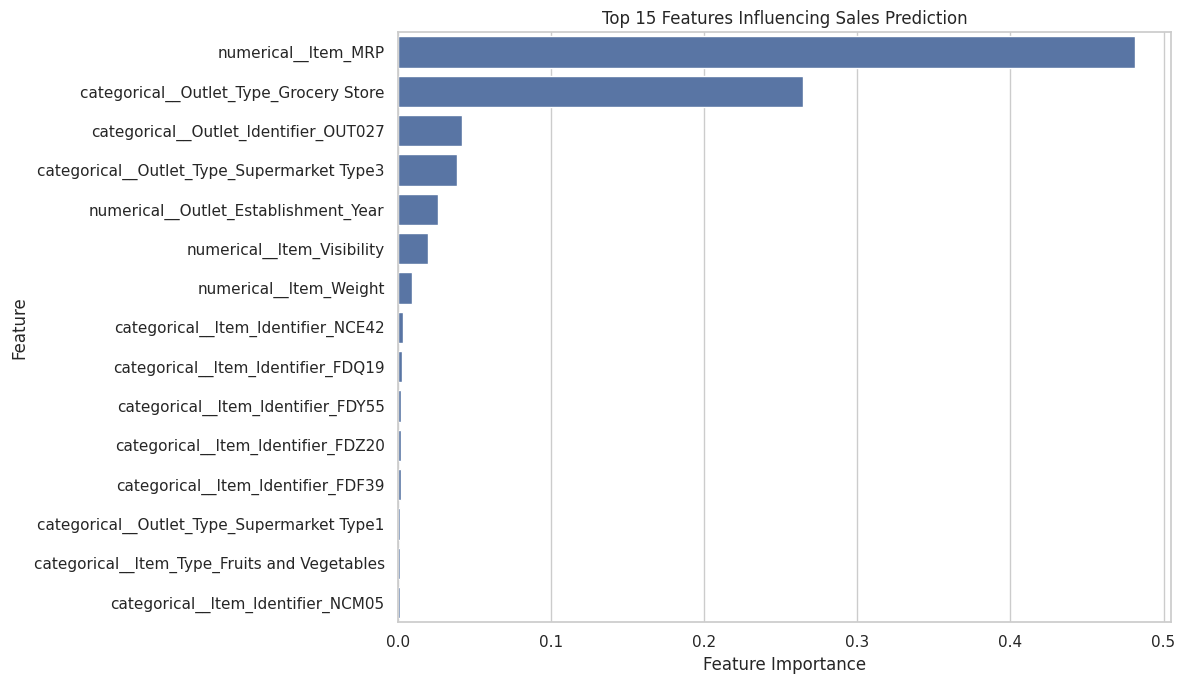

In [49]:
# ============================================
# FEATURE IMPORTANCE VISUALIZATION
# ============================================

# Extract feature names after preprocessing
feature_names = (
    random_forest_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

# Extract Random Forest feature importance values
importance_values = (
    random_forest_model
    .named_steps["model"]
    .feature_importances_
)

# Create feature importance table
feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance_values
})

# Sort by importance
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Select top 15 features
top_features = feature_importance.head(15)

# Plot
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title("Top 15 Features Influencing Sales Prediction")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()


In [50]:
# Make sure test data has the same preprocessing

X_test = test.copy()

print("Test data shape:", X_test.shape)

Test data shape: (5681, 11)


In [51]:
test_predictions = random_forest_model.predict(
    X_test
)

print("Predictions generated successfully.")

print("\nFirst 10 predictions:")
print(test_predictions[:10])

Predictions generated successfully.

First 10 predictions:
[1616.32113021 1309.42377061  504.37609376 2268.77241877 6334.81845662
 1902.44165299  648.15788316 1927.14167311 1410.56905161 3085.22469758]


In [52]:
prediction_output = test.copy()

prediction_output["Predicted_Item_Outlet_Sales"] = (
    test_predictions
)

prediction_output.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Predicted_Item_Outlet_Sales
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1616.321130
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,1309.423771
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,504.376094
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,2268.772419
4,FDY38,12.500,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,6334.818457


In [53]:
import os

# ============================================
# CREATE AND SAVE SALES PREDICTIONS
# ============================================

# Generate predictions using the trained Random Forest model
test_predictions = random_forest_model.predict(X_test)

# Create a copy of the test dataset
prediction_output = test.copy()

# Add predicted sales column
prediction_output["Predicted_Item_Outlet_Sales"] = test_predictions

# Display first 10 predictions
print("First 10 predictions:")
display(prediction_output.head(10))

# Save predictions to Google Drive
output_path = (
    "/content/drive/MyDrive/"
    "Thiranex/Task-4/BigMart Sales/"
    "bigmart_sales_predictions.csv"
)

# Extract the directory path
output_dir = os.path.dirname(output_path)

# Create the directory if it does not exist
os.makedirs(output_dir, exist_ok=True)

prediction_output.to_csv(
    output_path,
    index=False
)

print("\nPrediction file saved successfully!")
print("Saved to:")
print(output_path)

First 10 predictions:


,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Predicted_Item_Outlet_Sales
0,FDW58,20.750,Low Fat,0.007565,Snack Foods,107.8622,OUT049,1999,Medium,Tier 1,Supermarket Type1,1616.321130
1,FDW14,8.300,Regular,0.038428,Dairy,87.3198,OUT017,2007,Medium,Tier 2,Supermarket Type1,1309.423771
2,NCN55,14.600,Low Fat,0.099575,Others,241.7538,OUT010,1998,Medium,Tier 3,Grocery Store,504.376094
3,FDQ58,7.315,Low Fat,0.015388,Snack Foods,155.0340,OUT017,2007,Medium,Tier 2,Supermarket Type1,2268.772419
4,FDY38,12.500,Regular,0.118599,Dairy,234.2300,OUT027,1985,Medium,Tier 3,Supermarket Type3,6334.818457
5,FDH56,9.800,Regular,0.063817,Fruits and Vegetables,117.1492,OUT046,1997,Small,Tier 1,Supermarket Type1,1902.441653
6,FDL48,19.350,Regular,0.082602,Baking Goods,50.1034,OUT018,2009,Medium,Tier 3,Supermarket Type2,648.157883
7,FDC48,12.500,Low Fat,0.015782,Baking Goods,81.0592,OUT027,1985,Medium,Tier 3,Supermarket Type3,1927.141673
8,FDN33,6.305,Regular,0.123365,Snack Foods,95.7436,OUT045,2002,Medium,Tier 2,Supermarket Type1,1410.569052
9,FDA36,5.985,Low Fat,0.005698,Baking Goods,186.8924,OUT017,2007,Medium,Tier 2,Supermarket Type1,3085.224698



Prediction file saved successfully!
Saved to:
/content/drive/MyDrive/Thiranex/Task-4/BigMart Sales/bigmart_sales_predictions.csv


In [54]:
# ============================================
# FINAL BUSINESS INSIGHTS
# ============================================

# Find best model based on highest R² Score
best_model_name = results_df.loc[
    results_df["R2 Score"].idxmax(),
    "Model"
]

best_r2 = results_df["R2 Score"].max()

# Highest average sales by outlet type
best_outlet_type = avg_sales_outlet.idxmax()

# Highest average sales item type
best_item_type = avg_sales_item_type.idxmax()

# Highest average sales location
best_location = avg_sales_location.idxmax()

# Highest average sales fat category
best_fat_category = avg_sales_fat.idxmax()

# Highest Item MRP
highest_mrp = df["Item_MRP"].max()

# Overall average sales
overall_average_sales = df["Item_Outlet_Sales"].mean()


# ============================================
# DISPLAY BUSINESS INSIGHTS
# ============================================

print("========== BUSINESS INSIGHTS ==========")

print(
    f"Average Item Outlet Sales: "
    f"{overall_average_sales:.2f}"
)

print(
    f"Outlet type with highest average sales: "
    f"{best_outlet_type}"
)

print(
    f"Item type with highest average sales: "
    f"{best_item_type}"
)

print(
    f"Location type with highest average sales: "
    f"{best_location}"
)

print(
    f"Fat-content category with highest average sales: "
    f"{best_fat_category}"
)

print(
    f"Highest Item MRP in dataset: "
    f"{highest_mrp:.2f}"
)

print(
    f"Best machine learning model: "
    f"{best_model_name}"
)

print(
    f"Best model R² score: "
    f"{best_r2:.4f}"
)

========== BUSINESS INSIGHTS ==========
Average Item Outlet Sales: 2181.29
Outlet type with highest average sales: Supermarket Type3
Item type with highest average sales: Starchy Foods
Location type with highest average sales: Tier 2
Fat-content category with highest average sales: Regular
Highest Item MRP in dataset: 266.89
Best machine learning model: Random Forest
Best model R² score: 0.6052


In [55]:
final_summary = pd.DataFrame({
    "Metric": [
        "Total Training Records",
        "Total Test Records",
        "Number of Features",
        "Average Sales",
        "Best Outlet Type",
        "Best Item Type",
        "Best Location Type",
        "Best Fat Content Category",
        "Best ML Model",
        "Best R² Score"
    ],
    "Value": [
        len(df),
        len(test),
        X.shape[1],
        round(overall_average_sales, 2),
        best_outlet_type,
        best_item_type,
        best_location,
        best_fat_category,
        best_model_name,
        round(best_r2, 4)
    ]
})

final_summary

,Metric,Value
0,Total Training Records,8523
1,Total Test Records,5681
2,Number of Features,11
3,Average Sales,2181.29
4,Best Outlet Type,Supermarket Type3
5,Best Item Type,Starchy Foods
6,Best Location Type,Tier 2
7,Best Fat Content Category,Regular
8,Best ML Model,Random Forest
9,Best R² Score,0.6052


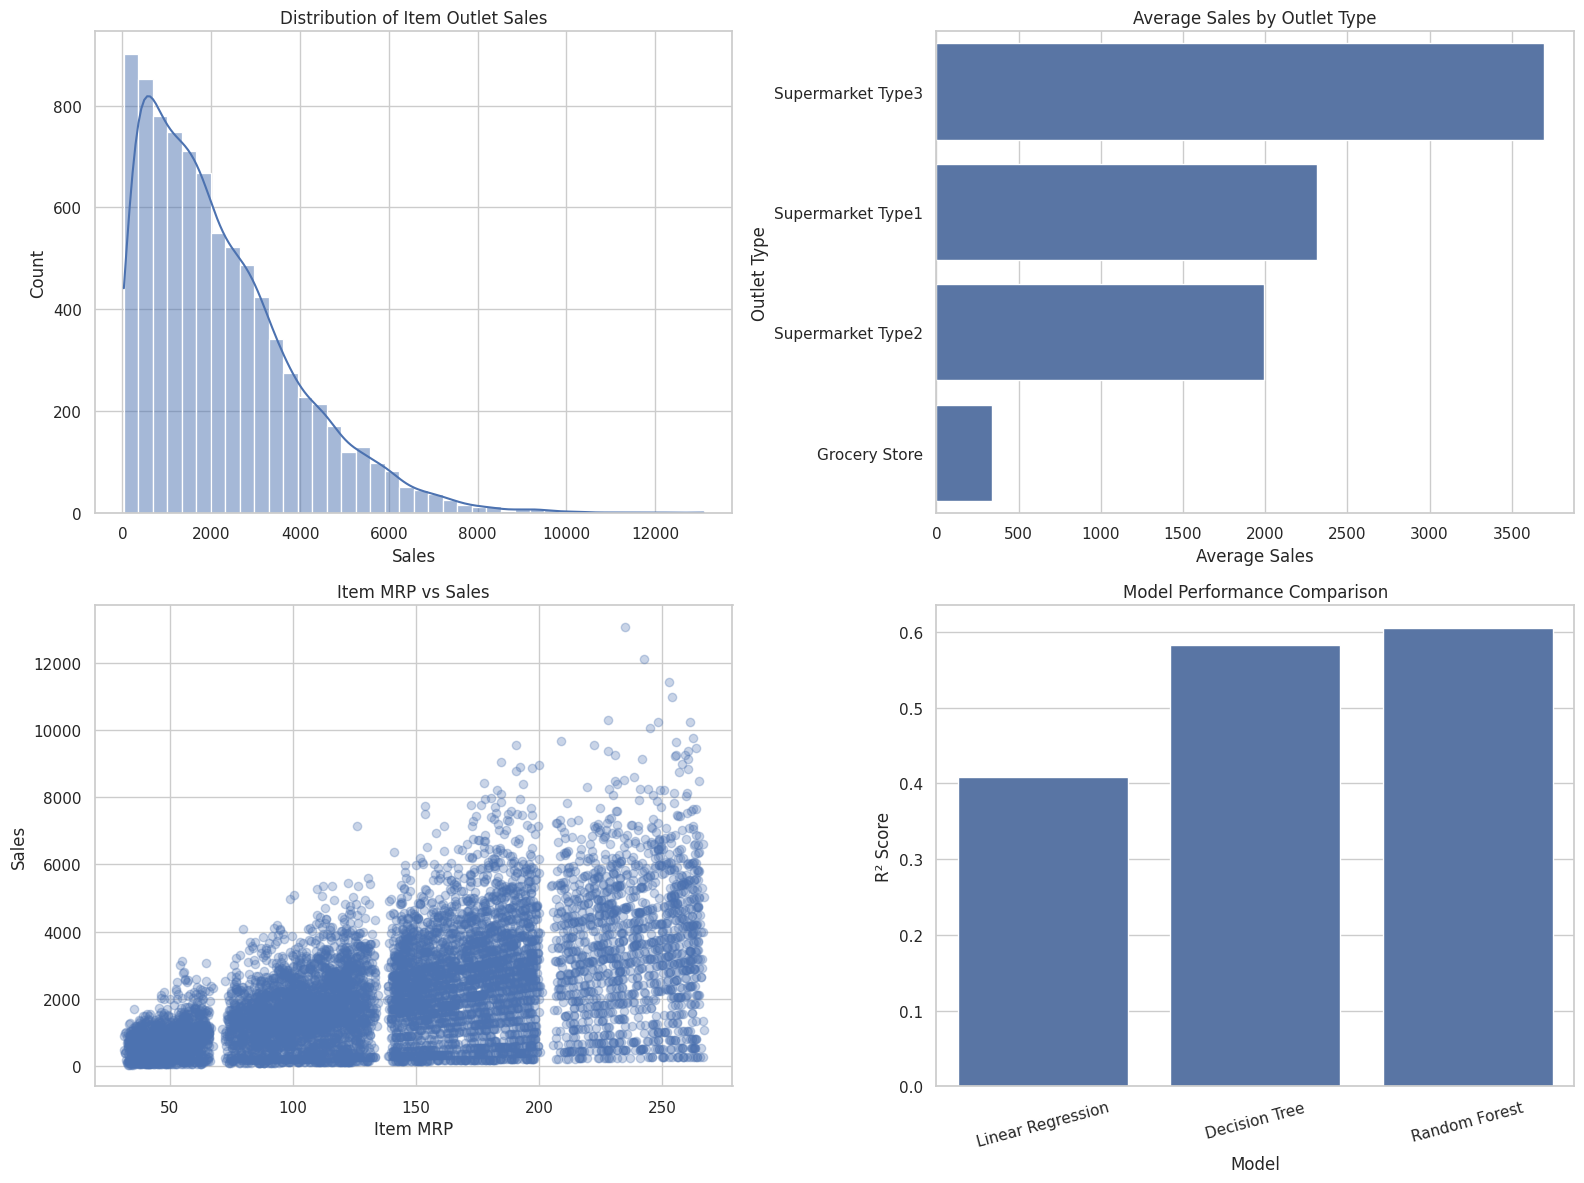

In [56]:
fig, axes = plt.subplots(
    2,
    2,
    figsize=(16, 12)
)

# 1. Sales Distribution
sns.histplot(
    df["Item_Outlet_Sales"],
    bins=40,
    kde=True,
    ax=axes[0, 0]
)

axes[0, 0].set_title(
    "Distribution of Item Outlet Sales"
)
axes[0, 0].set_xlabel("Sales")
axes[0, 0].set_ylabel("Count")


# 2. Average Sales by Outlet Type
sns.barplot(
    x=avg_sales_outlet.values,
    y=avg_sales_outlet.index,
    ax=axes[0, 1]
)

axes[0, 1].set_title(
    "Average Sales by Outlet Type"
)
axes[0, 1].set_xlabel("Average Sales")
axes[0, 1].set_ylabel("Outlet Type")


# 3. MRP vs Sales
axes[1, 0].scatter(
    df["Item_MRP"],
    df["Item_Outlet_Sales"],
    alpha=0.3
)

axes[1, 0].set_title(
    "Item MRP vs Sales"
)
axes[1, 0].set_xlabel("Item MRP")
axes[1, 0].set_ylabel("Sales")


# 4. Model Comparison
sns.barplot(
    data=results_df,
    x="Model",
    y="R2 Score",
    ax=axes[1, 1]
)

axes[1, 1].set_title(
    "Model Performance Comparison"
)
axes[1, 1].set_xlabel("Model")
axes[1, 1].set_ylabel("R² Score")

axes[1, 1].tick_params(
    axis="x",
    rotation=15
)

plt.tight_layout()

plt.show()

# Conclusion

The Big Mart Sales Analysis and Prediction project applied an end-to-end data science workflow to a real-world retail dataset.

The analysis began with data inspection and cleaning, followed by exploratory data analysis to understand item characteristics, outlet types, outlet locations, pricing, visibility, and sales patterns.

Several visualizations were created to identify important trends and relationships. The analysis examined average sales across item types, outlet types, location types, fat-content categories, and outlet establishment years. Correlation analysis and scatter plots were also used to study relationships between numerical variables such as Item MRP, Item Visibility, and Item Outlet Sales.

Three regression models were developed:
- Linear Regression
- Decision Tree Regression
- Random Forest Regression

The models were evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. The model with the highest R² Score was selected as the best-performing model.

The project demonstrates how data cleaning, exploratory analysis, visualization, feature engineering, machine learning, and model evaluation can be combined to solve a practical retail sales prediction problem.

The resulting insights can help understand the factors associated with sales performance and demonstrate how machine learning can support data-driven retail decision-making.